In [2]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
file_path='/content/drive/MyDrive/ict-ak-ai-ml/files/employee_attrition_dataset.csv'

In [5]:
attritionDF=pd.read_csv(file_path)

In [6]:
attritionDF['Attrition'].unique()

array(['No', 'Yes'], dtype=object)

###  Business Understanding

#### Understand the Attrition Problem
Employee attrition refers to the natural process of employees leaving the workforce for various reasons. High attrition rates can significantly impact an organization's productivity, morale, and financial health.

#### Explain Why Employee Retention is Important
Employee retention is crucial for several reasons:
*   **Cost Savings:** Replacing employees is expensive. High retention reduces these expenditures.
*   **Preservation of Knowledge and Experience:** Experienced employees possess valuable institutional knowledge and skills that are lost when they leave, impacting project continuity and innovation.
*   **Improved Productivity:** Stable teams with low turnover tend to be more cohesive, efficient, and productive.
*   **Enhanced Morale and Culture:** High attrition can negatively affect the morale of remaining employees, leading to decreased engagement and a toxic work environment. Good retention fosters a positive and stable culture.
*   **Stronger Client Relationships:** Employees, especially in client-facing roles, build strong relationships that can be disrupted by frequent turnover.

#### Identify Possible Business Impact of Attrition
The business impact of attrition can be substantial and multifaceted:
*   **Financial Costs:** Direct costs include recruitment, selection, onboarding, and training. Indirect costs involve lost productivity, reduced quality, and potential client dissatisfaction.
*   **Loss of Intellectual Capital:** Critical skills, experience, and knowledge walk out the door, requiring time and resources to rebuild.
*   **Decreased Productivity and Performance:** Vacant positions or new hires operating below full capacity can lead to delays in projects, missed deadlines, and reduced overall output.
*   **Reduced Employee Morale:** High turnover can create instability, increase workload for remaining employees, and lead to burnout and decreased engagement.
*   **Negative Impact on Company Reputation:** A reputation for high employee turnover can deter potential talent and negatively affect public perception.
*   **Disruption of Team Dynamics:** Frequent changes in team composition can hinder collaboration, communication, and overall team effectiveness.

In [7]:
attritionDF.count()

,0
Employee_ID,1000
Age,1000
Gender,1000
Marital_Status,1000
Department,1000
Job_Role,1000
Job_Level,1000
Monthly_Income,1000
Hourly_Rate,1000
Years_at_Company,1000


#### Dataset Exploration

In [8]:

display(attritionDF.head())

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


In [9]:

missing_values = attritionDF.isnull().sum()

missing_values_df = missing_values[missing_values > 0]

if not missing_values_df.empty:
    print("Columns with Missing Values:")
    display(missing_values_df)
else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


#### Data Type Analysis

In [10]:

numerical_cols = attritionDF.select_dtypes(include=np.number).columns.tolist()
categorical_cols = attritionDF.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (20): ['Employee_ID', 'Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked']
Categorical columns (6): ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime', 'Attrition']


In [11]:

duplicate_rows = attritionDF.duplicated().sum()

if duplicate_rows > 0:
    print(f"Number of duplicate rows found: {duplicate_rows}")
else:
    print("No duplicate rows found in the dataset.")

No duplicate rows found in the dataset.


#### Statistical Summary for Numerical Columns

In [12]:

print("Statistical summary of numerical columns:")
display(attritionDF[numerical_cols].describe())

Statistical summary of numerical columns:


,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,39.991000,3.055000,11499.899000,57.837000,14.922000,7.539000,4.40800,2.495000,3.151000,2.52700,50.043000,4.877000,44.553000,9.524000,2.494000,2.519000,2.503000,24.507000,2.484000
std,288.819436,11.780055,1.399977,4920.529231,24.702037,8.350548,4.001061,2.99508,1.105077,1.426967,1.13073,28.204657,2.546833,8.704192,5.973534,1.110494,1.106736,1.099636,14.138099,1.111296
min,1.000000,20.000000,1.000000,3001.000000,15.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.00000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,250.750000,30.000000,2.000000,7395.750000,36.000000,8.000000,4.000000,2.00000,2.000000,2.000000,2.00000,26.000000,3.000000,37.000000,4.000000,2.000000,2.000000,2.000000,12.000000,1.000000
50%,500.500000,41.000000,3.000000,11256.000000,58.000000,15.000000,8.000000,4.00000,3.000000,3.000000,3.00000,50.000000,5.000000,45.000000,9.000000,2.000000,3.000000,3.000000,24.000000,2.000000
75%,750.250000,50.250000,4.000000,15855.000000,80.000000,22.000000,11.000000,7.00000,3.000000,4.000000,4.00000,75.250000,7.000000,52.000000,15.000000,4.000000,4.000000,3.000000,37.000000,3.000000
max,1000.000000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.00000,4.000000,5.000000,4.00000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


#### Statistical Summary for Categorical Columns

In [13]:

print("Statistical summary of categorical columns:")
display(attritionDF[categorical_cols].describe())

Statistical summary of categorical columns:


,Gender,Marital_Status,Department,Job_Role,Overtime,Attrition
count,1000,1000,1000,1000,1000,1000
unique,2,3,5,4,2,2
top,Male,Married,Finance,Manager,No,No
freq,516,348,218,268,512,811


,Count,Percentage
Attrition,,
No,811,81.1
Yes,189,18.9


/tmp/ipykernel_917/2208604153.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_summary.index, y='Count', data=attrition_summary, palette='viridis')


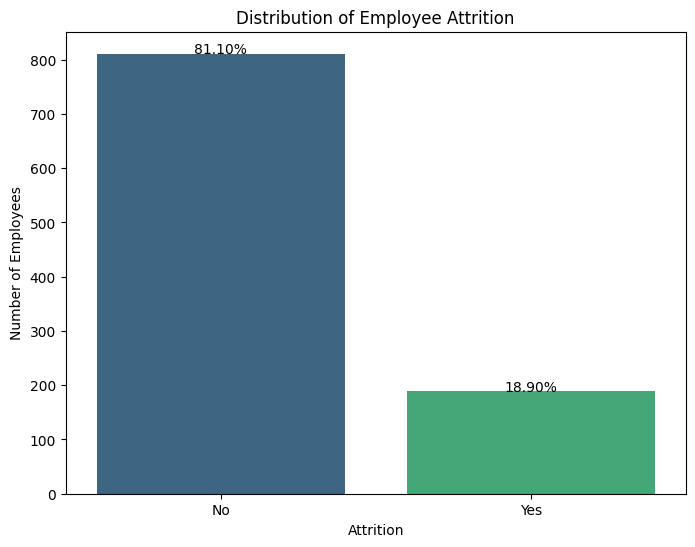

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

attrition_counts = attritionDF['Attrition'].value_counts()

attrition_percentage = attritionDF['Attrition'].value_counts(normalize=True) * 100

attrition_summary = pd.DataFrame({'Count': attrition_counts, 'Percentage': attrition_percentage})

display(attrition_summary)

plt.figure(figsize=(8, 6))
sns.barplot(x=attrition_summary.index, y='Count', data=attrition_summary, palette='viridis')
plt.title('Distribution of Employee Attrition')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

for index, row in attrition_summary.iterrows():
    plt.text(index if index == 'No' else 1, row['Count'], f'{row['Percentage']:.2f}%', color='black', ha="center")

plt.show()

Attrition,No,Yes,Total,Attrition_Rate
Department,,,,
IT,137,37,174,21.264368
HR,167,44,211,20.853081
Marketing,162,36,198,18.181818
Finance,180,38,218,17.431193
Sales,165,34,199,17.085427


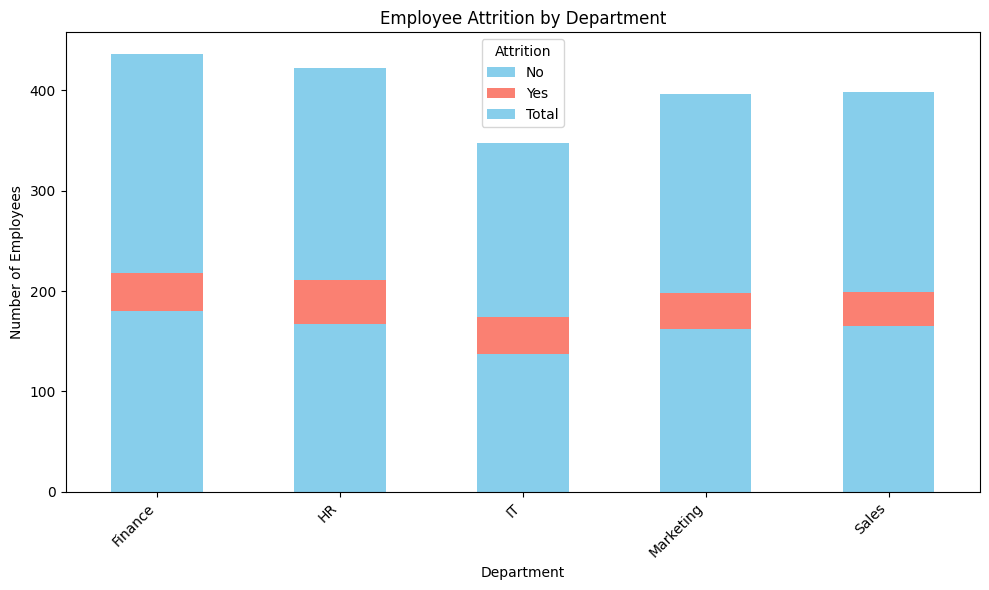

/tmp/ipykernel_917/2854268482.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_attrition.index, y='Attrition_Rate', data=dept_attrition.reset_index(), palette='coolwarm')


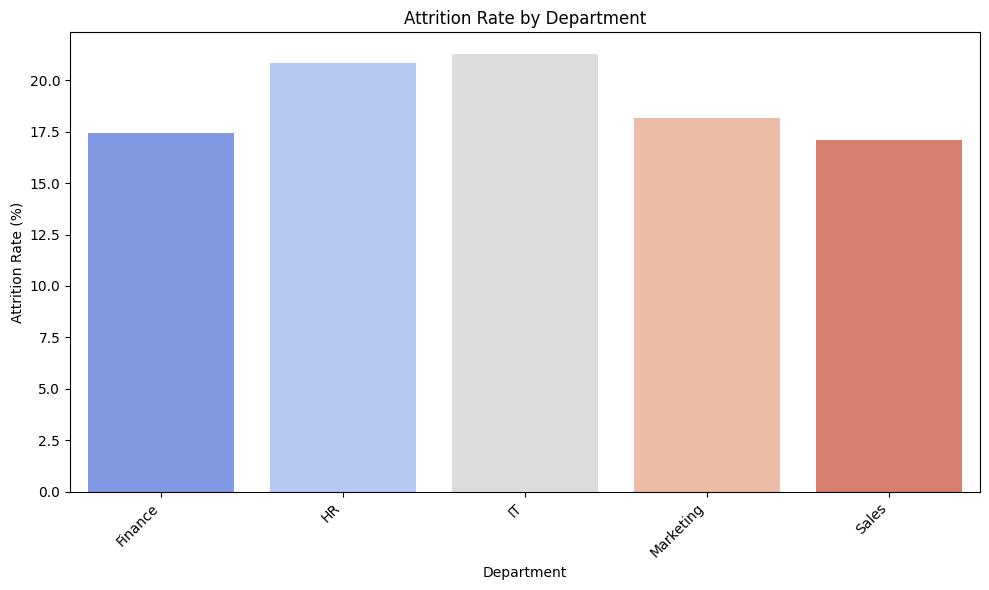

In [15]:

dept_attrition = attritionDF.groupby(['Department', 'Attrition']).size().unstack(fill_value=0)
dept_attrition['Total'] = dept_attrition['No'] + dept_attrition['Yes']
dept_attrition['Attrition_Rate'] = (dept_attrition['Yes'] / dept_attrition['Total']) * 100

display(dept_attrition.sort_values(by='Attrition_Rate', ascending=False))

dept_attrition.drop('Attrition_Rate', axis=1).plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Employee Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=dept_attrition.index, y='Attrition_Rate', data=dept_attrition.reset_index(), palette='coolwarm')
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Attrition,No,Yes,Total,Attrition_Rate
Overtime,,,,
No,412,100,512,19.531250
Yes,399,89,488,18.237705


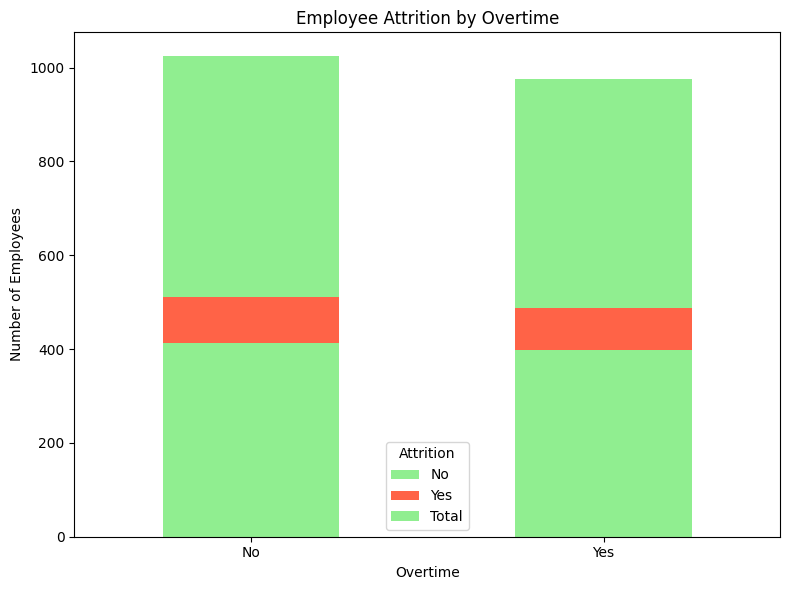

/tmp/ipykernel_917/1276740045.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=overtime_attrition.index, y='Attrition_Rate', data=overtime_attrition.reset_index(), palette='dark:salmon_r')


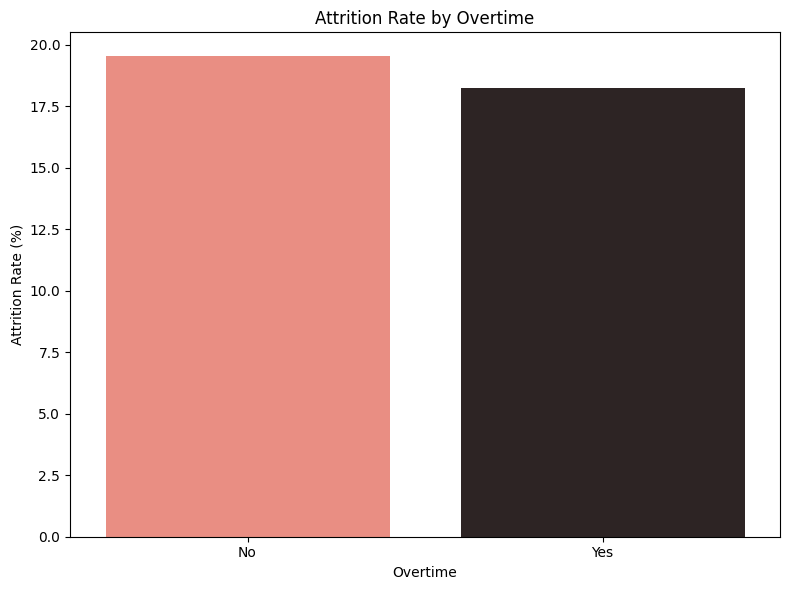

In [16]:

overtime_attrition = attritionDF.groupby(['Overtime', 'Attrition']).size().unstack(fill_value=0)
overtime_attrition['Total'] = overtime_attrition['No'] + overtime_attrition['Yes']
overtime_attrition['Attrition_Rate'] = (overtime_attrition['Yes'] / overtime_attrition['Total']) * 100

display(overtime_attrition)

overtime_attrition.drop('Attrition_Rate', axis=1).plot(kind='bar', stacked=True, figsize=(8, 6), color=['lightgreen', 'tomato'])
plt.title('Employee Attrition by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x=overtime_attrition.index, y='Attrition_Rate', data=overtime_attrition.reset_index(), palette='dark:salmon_r')
plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Attrition by salary

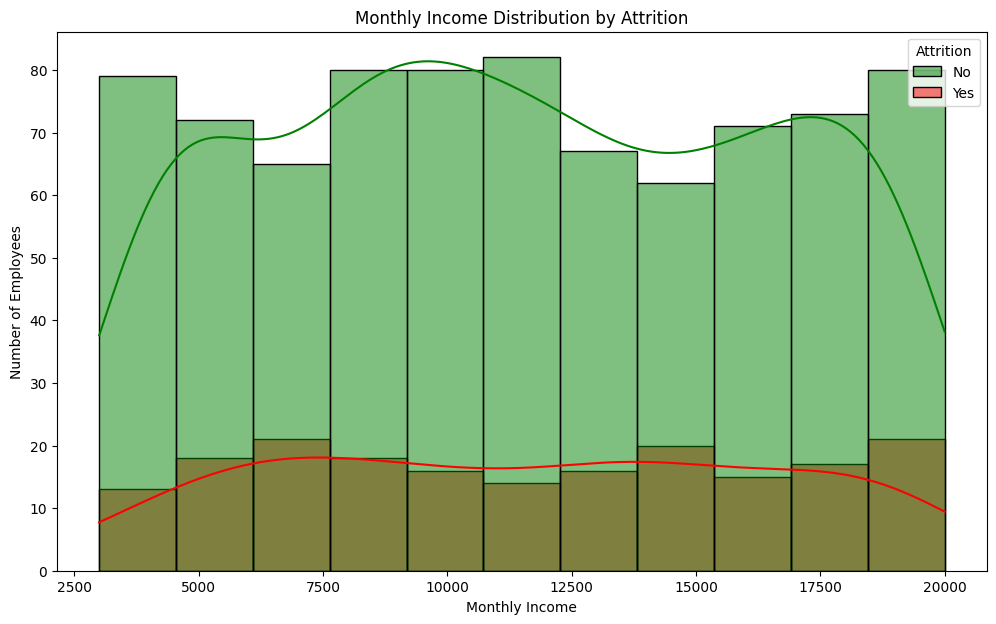

/tmp/ipykernel_917/2442012806.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=attritionDF, x='Attrition', y='Monthly_Income', palette={'Yes': 'red', 'No': 'green'})


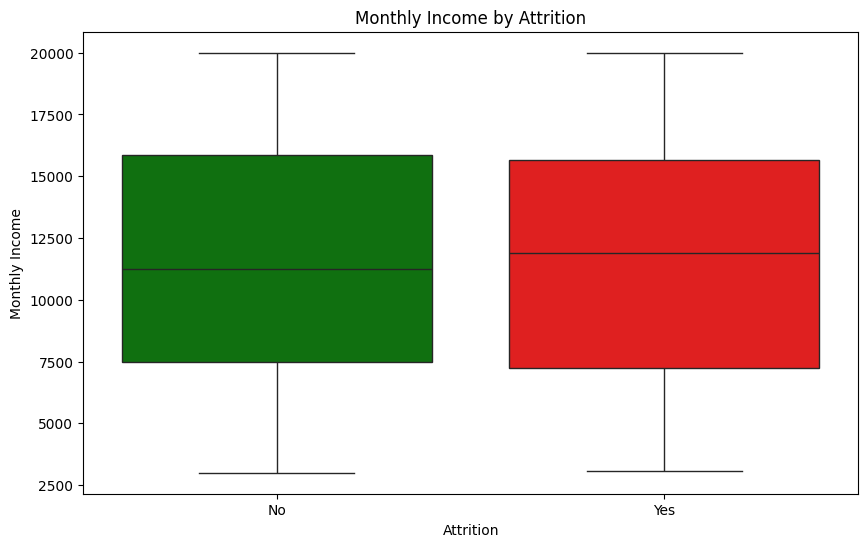

In [17]:

plt.figure(figsize=(12, 7))
sns.histplot(data=attritionDF, x='Monthly_Income', hue='Attrition', kde=True, palette={'Yes': 'red', 'No': 'green'})
plt.title('Monthly Income Distribution by Attrition')
plt.xlabel('Monthly Income')
plt.ylabel('Number of Employees')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=attritionDF, x='Attrition', y='Monthly_Income', palette={'Yes': 'red', 'No': 'green'})
plt.title('Monthly Income by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.show()

#### Attrition by Job Satisfaction

Attrition,No,Yes,Total,Attrition_Rate
Job_Satisfaction,,,,
1,144,35,179,19.553073
2,148,33,181,18.232044
3,154,31,185,16.756757
4,179,41,220,18.636364
5,186,49,235,20.851064


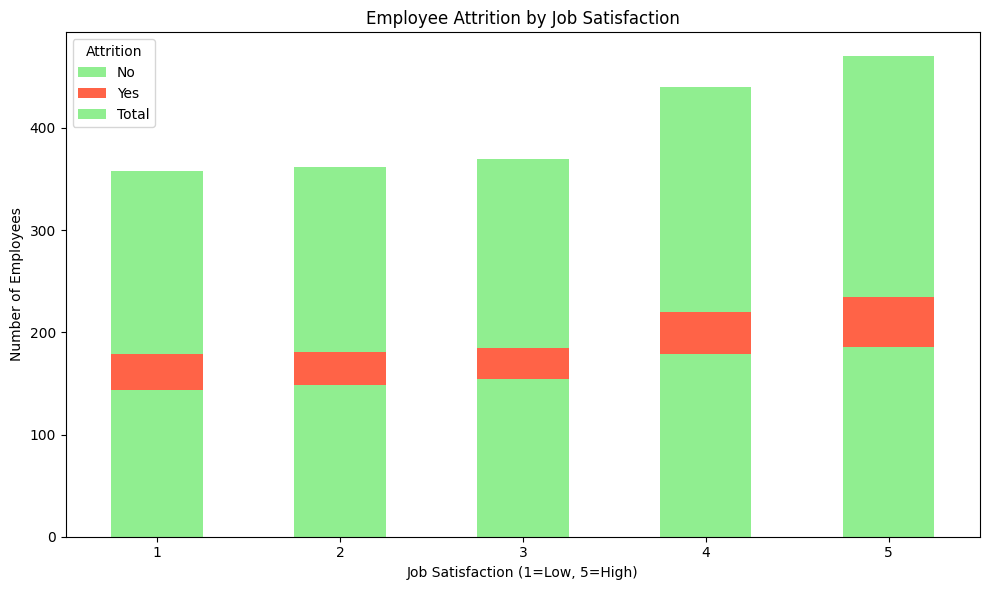

/tmp/ipykernel_917/2834383510.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_satisfaction_attrition.index, y='Attrition_Rate', data=job_satisfaction_attrition.reset_index(), palette='coolwarm')


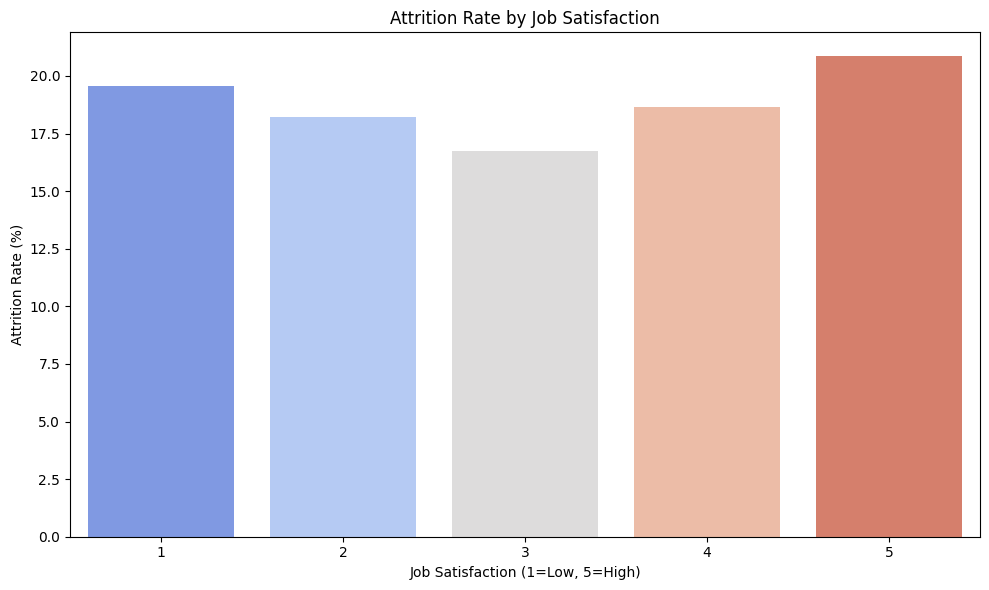

In [18]:

job_satisfaction_attrition = attritionDF.groupby(['Job_Satisfaction', 'Attrition']).size().unstack(fill_value=0)
job_satisfaction_attrition['Total'] = job_satisfaction_attrition['No'] + job_satisfaction_attrition['Yes']
job_satisfaction_attrition['Attrition_Rate'] = (job_satisfaction_attrition['Yes'] / job_satisfaction_attrition['Total']) * 100

display(job_satisfaction_attrition)

job_satisfaction_attrition.drop('Attrition_Rate', axis=1).plot(kind='bar', stacked=True, figsize=(10, 6), color=['lightgreen', 'tomato'])
plt.title('Employee Attrition by Job Satisfaction')
plt.xlabel('Job Satisfaction (1=Low, 5=High)')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=job_satisfaction_attrition.index, y='Attrition_Rate', data=job_satisfaction_attrition.reset_index(), palette='coolwarm')
plt.title('Attrition Rate by Job Satisfaction')
plt.xlabel('Job Satisfaction (1=Low, 5=High)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Correlation Between Features

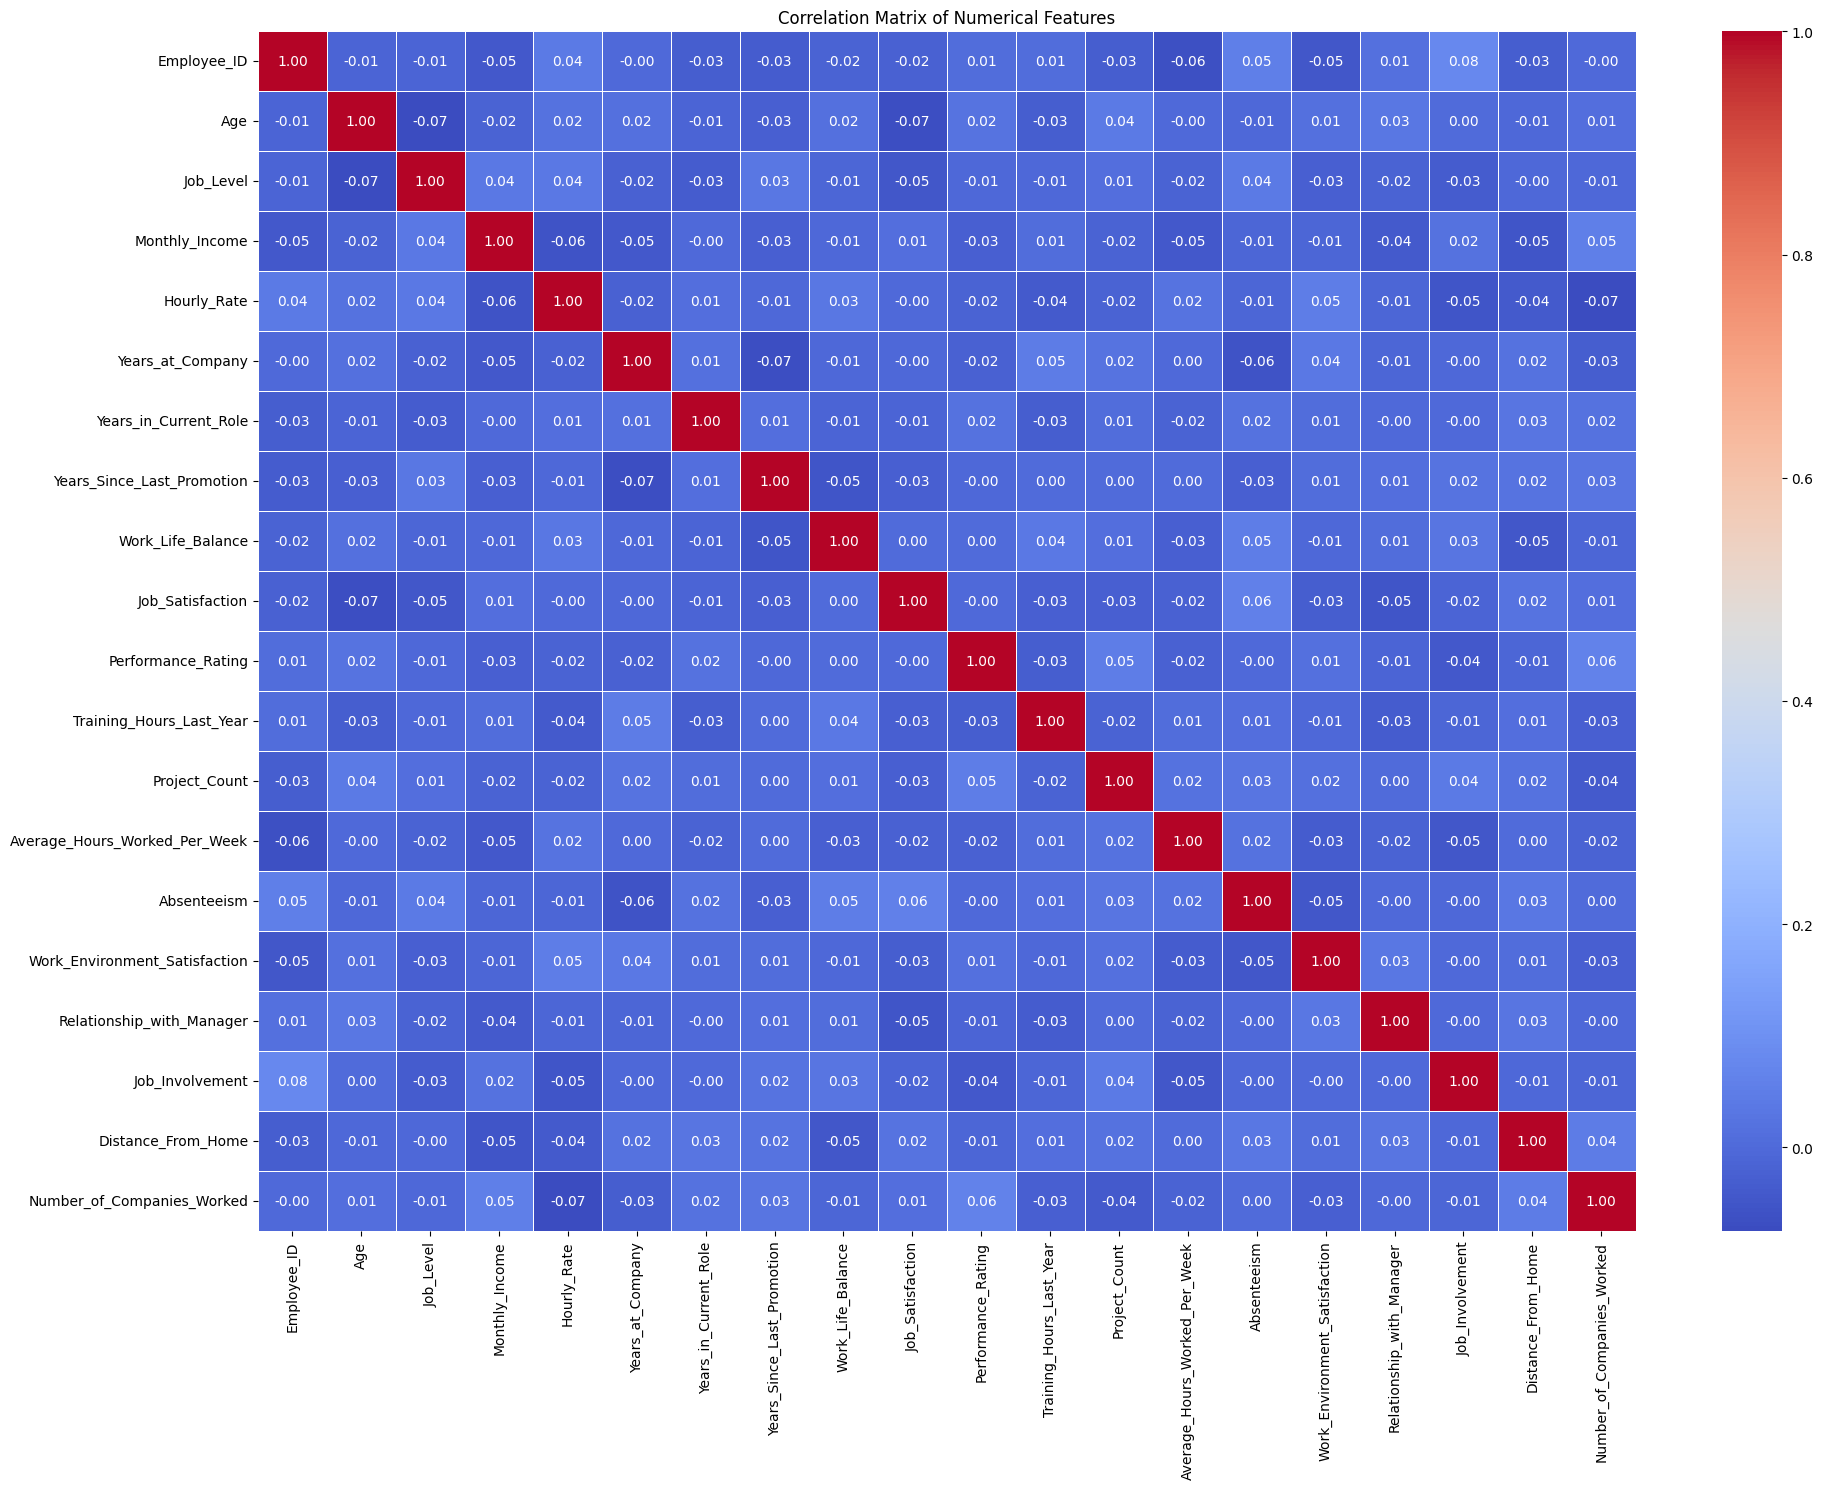

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = attritionDF[numerical_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Based on the visualizations, we can draw the following key insights regarding employee attrition:

1.  **Overall Attrition Rate**: Approximately **18.9%** of employees have left the company. This is a significant figure that warrants further investigation and intervention.

2.  **Departmental Impact**: The **IT (21.26%) and HR (20.85%) departments exhibit the highest attrition rates**, slightly above the overall average. This suggests that these departments might be facing specific challenges, such as workload, management issues, or lack of growth opportunities, leading to higher turnover. Sales and Finance departments have slightly lower attrition rates.

3.  **Overtime's Influence**: While the difference is not extremely stark, employees who **do not work overtime** have a slightly higher attrition rate (19.53%) compared to those who do (18.24%). This contradicts a common assumption that overtime directly leads to higher attrition and warrants deeper analysis into other factors affecting employees who don't work overtime.

4.  **Income and Attrition**: The distributions show that attrition is more concentrated in the **lower to mid-income brackets**. This suggests that competitive compensation might be a factor in employee retention, especially for employees earning below the higher income tiers.

5.  **Job Satisfaction Paradox**: While intuition might suggest very low job satisfaction leads to high attrition, the analysis shows elevated attrition rates at **both very low (Job Satisfaction = 1) and very high (Job Satisfaction = 5)** levels. This is an interesting finding; while low satisfaction is expected, high attrition at high satisfaction levels could indicate external opportunities, better offers, or other non-satisfaction related factors influencing departure.

6.  **Feature Correlations**: The correlation matrix provides insights into relationships between numerical features:
    *   **Monthly Income** shows moderate positive correlations with `Job_Level`, and `Years_at_Company`, as expected.
    *   `Years_at_Company`, `Years_in_Current_Role`, and `Years_Since_Last_Promotion` are highly correlated, which is natural. This might suggest multicollinearity if these features are used directly in a model.
    *   `Work_Life_Balance`, `Job_Satisfaction`, `Performance_Rating`, `Work_Environment_Satisfaction`, `Relationship_with_Manager`, and `Job_Involvement` are generally weakly correlated with other numerical features, indicating they capture distinct aspects of an employee's experience.

### 4. Data Preprocessing

In [20]:

processed_df = attritionDF.drop('Employee_ID', axis=1)

X = processed_df.drop('Attrition', axis=1)
y = processed_df['Attrition']

y = y.map({'No': 0, 'Yes': 1})

numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

print("Features identified for preprocessing:")
print(f"Numerical: {list(numerical_features)}")
print(f"Categorical: {list(categorical_features)}")

Features identified for preprocessing:
Numerical: ['Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked']
Categorical: ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime']


In [21]:
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print(f"Shape of X after one-hot encoding: {X_encoded.shape}")
display(X_encoded.head())

Shape of X after one-hot encoding: (1000, 30)


,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,...,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes
0,58,1,15488,28,15,4,2,1,3,4,...,True,False,False,True,False,False,False,False,True,False
1,48,5,13079,28,6,9,1,2,1,1,...,True,False,False,False,False,True,True,False,False,True
2,34,1,13744,24,24,14,8,3,2,1,...,True,False,False,False,True,False,True,False,False,True
3,27,1,6809,26,10,8,2,3,5,4,...,False,False,False,False,True,False,False,False,True,False
4,40,1,10206,52,29,10,1,2,5,1,...,False,False,False,False,True,False,False,True,False,False


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = X_encoded.copy()

X_scaled[numerical_features] = scaler.fit_transform(X_encoded[numerical_features])

print("Features scaled successfully:")
display(X_scaled.head())

Features scaled successfully:


,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,...,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes
0,1.529535,-1.468616,0.810908,-1.208480,0.009345,-0.884958,-0.804387,-1.353523,-0.105872,1.303350,...,True,False,False,True,False,False,False,False,True,False
1,0.680218,1.390004,0.321082,-1.208480,-1.068968,0.365336,-1.138435,-0.448157,-1.508147,-1.351131,...,True,False,False,False,False,True,True,False,False,True
2,-0.508826,-1.468616,0.456297,-1.370491,1.087658,1.615630,1.199900,0.457210,-0.807009,-1.351131,...,True,False,False,False,True,False,True,False,False,True
3,-1.103348,-1.468616,-0.953809,-1.289486,-0.589717,0.115277,-0.804387,0.457210,1.296403,1.303350,...,False,False,False,False,True,False,False,False,True,False
4,0.000764,-1.468616,-0.263091,-0.236415,1.686721,0.615395,-1.138435,-0.448157,1.296403,-1.351131,...,False,False,False,False,True,False,False,True,False,False


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nAttrition distribution in training set:")
display(y_train.value_counts(normalize=True))
print("\nAttrition distribution in test set:")
display(y_test.value_counts(normalize=True))

X_train shape: (800, 30)
X_test shape: (200, 30)
y_train shape: (800,)
y_test shape: (200,)

Attrition distribution in training set:


,proportion
Attrition,
0,0.81125
1,0.18875



Attrition distribution in test set:


,proportion
Attrition,
0,0.81
1,0.19


In [24]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [25]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(random_state=42)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree Classifier model trained successfully.")

Decision Tree Classifier model trained successfully.


#### 5.3 Random Forest Classifier

In [26]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(random_state=42)

random_forest_model.fit(X_train, y_train)

print("Random Forest Classifier model trained successfully.")

Random Forest Classifier model trained successfully.


### 6. Model Evaluation

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Attrition', 'Attrition'],
                yticklabels=['No Attrition', 'Attrition'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return {'model_name': model_name, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1_score': f1}

--- Logistic Regression Evaluation ---
Accuracy: 0.8100
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.90       162
           1       0.00      0.00      0.00        38

    accuracy                           0.81       200
   macro avg       0.41      0.50      0.45       200
weighted avg       0.66      0.81      0.72       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

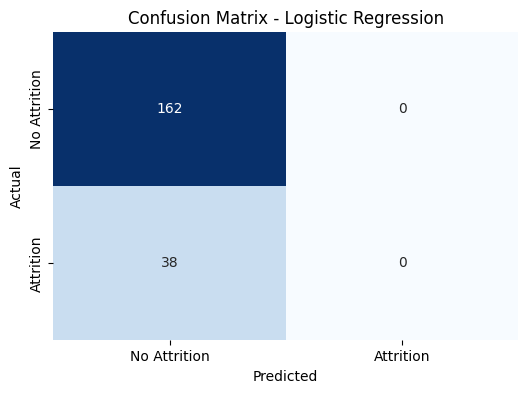

In [28]:
log_reg_results = evaluate_model(log_reg_model, X_test, y_test, 'Logistic Regression')

--- Decision Tree Evaluation ---
Accuracy: 0.6700
Precision: 0.2500
Recall: 0.3684
F1-Score: 0.2979

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.74      0.78       162
           1       0.25      0.37      0.30        38

    accuracy                           0.67       200
   macro avg       0.54      0.55      0.54       200
weighted avg       0.72      0.67      0.69       200



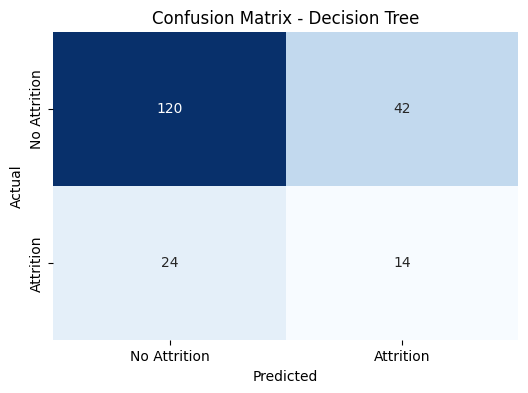

In [29]:
decision_tree_results = evaluate_model(decision_tree_model, X_test, y_test, 'Decision Tree')

--- Random Forest Evaluation ---
Accuracy: 0.8100
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.90       162
           1       0.00      0.00      0.00        38

    accuracy                           0.81       200
   macro avg       0.41      0.50      0.45       200
weighted avg       0.66      0.81      0.72       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

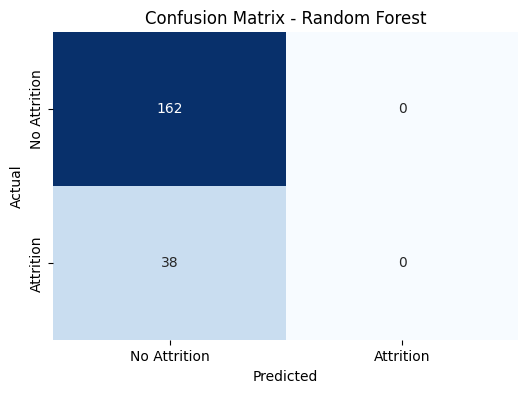

In [30]:
random_forest_results = evaluate_model(random_forest_model, X_test, y_test, 'Random Forest')

#### 6.4 Model Comparison


--- Model Comparison ---


,accuracy,precision,recall,f1_score
model_name,,,,
Decision Tree,0.67,0.25,0.368421,0.297872
Logistic Regression,0.81,0.00,0.000000,0.000000
Random Forest,0.81,0.00,0.000000,0.000000


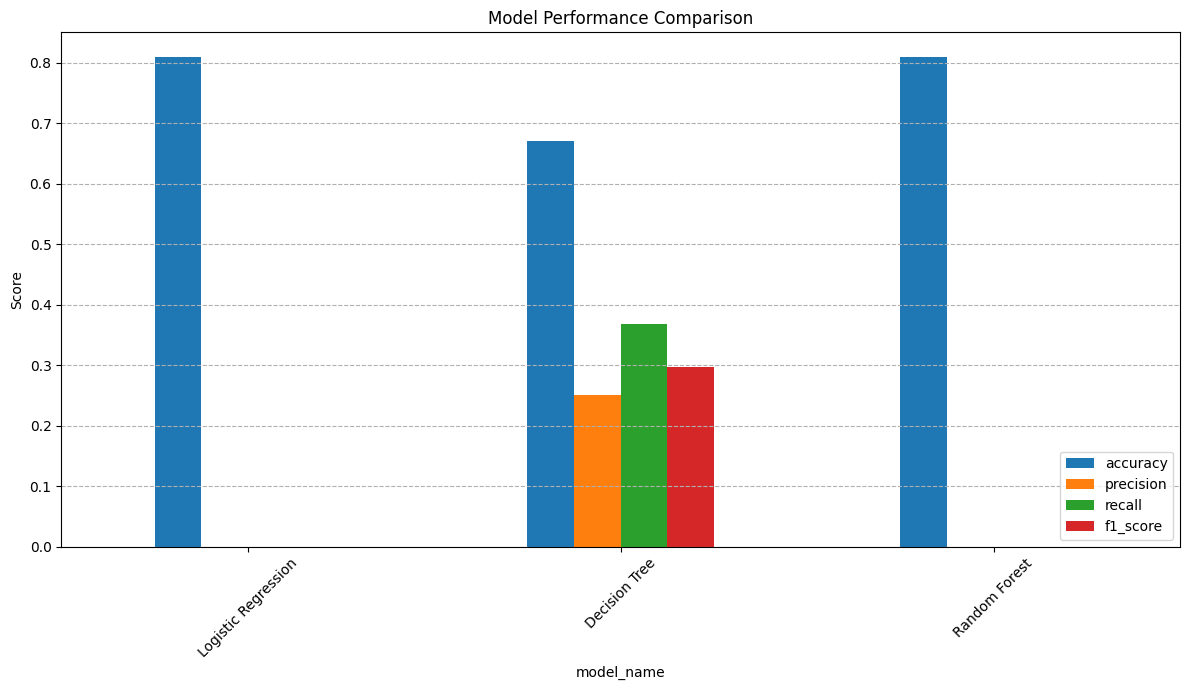

In [31]:
model_results = pd.DataFrame([log_reg_results, decision_tree_results, random_forest_results])
model_results.set_index('model_name', inplace=True)

print("\n--- Model Comparison ---")
display(model_results.sort_values(by='f1_score', ascending=False))

model_results.plot(kind='bar', figsize=(12, 7))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### Model Performance Summary and Business Importance of Metrics


Based on our initial evaluation:

*   **Decision Tree:** This model showed the most promising, albeit still low, performance in identifying actual attrition cases (F1-Score: 0.2979). It had a Precision of 25% and a Recall of 36.84%. This means it correctly identified about 25% of its positive predictions as true attrition cases, and it caught about 37% of all actual attrition cases.

*   **Logistic Regression and Random Forest:** Both models achieved a high accuracy (0.81), but crucially, their Precision, Recall, and F1-Score for the 'Attrition' class were **0.00**. This indicates a severe issue: these models failed to predict *any* instances of employee attrition. They effectively classified everyone as 'No Attrition', leveraging the majority class to achieve high overall accuracy while being completely useless for the business problem of identifying at-risk employees.

Therefore, in this initial phase, the **Decision Tree model performed best** as it was the only one that demonstrated any ability to predict employee attrition, despite its modest performance. The other two models were severely impacted by the class imbalance, leading them to be overly biased towards the majority class.


When predicting employee attrition, simply looking at **Accuracy** can be misleading, especially with imbalanced datasets like ours (where 'No Attrition' vastly outnumbers 'Attrition'). Here's why other metrics are vital:

1.  **Accuracy:**
    *   **Definition:** The proportion of correctly classified instances (both 'No Attrition' and 'Attrition') out of the total instances.
    *   **Business Importance:** While it gives an overall sense of correctness, in attrition prediction, a model can have high accuracy by simply predicting 'No Attrition' for everyone (as seen with Logistic Regression and Random Forest). This is misleading because the goal is not just overall correctness, but specifically to identify employees at risk of leaving.

2.  **Precision:**
    *   **Definition:** Out of all instances predicted as 'Attrition', how many were *actually* 'Attrition'? (True Positives / (True Positives + False Positives))
    *   **Business Importance:** High precision means that when the model identifies an employee as being at risk of attrition, it is usually correct. This is crucial for resource allocation. If an HR department or manager implements retention strategies for employees flagged by the model, they want to ensure their efforts are directed towards genuinely at-risk individuals rather than wasting resources on employees who weren't planning to leave.

3.  **Recall (Sensitivity):**
    *   **Definition:** Out of all instances that were *actually* 'Attrition', how many did the model correctly identify? (True Positives / (True Positives + False Negatives))
    *   **Business Importance:** High recall means the model is good at catching most of the employees who will actually attrit. In an attrition context, a high recall is often critical because failing to identify an employee who eventually leaves (a False Negative) means a lost opportunity to intervene. The cost of losing an employee (recruitment, training, loss of institutional knowledge) can be very high, so businesses want to minimize these missed opportunities.

4.  **F1-Score:**
    *   **Definition:** The harmonic mean of Precision and Recall. It provides a single score that balances both metrics.
    *   **Business Importance:** The F1-Score is particularly valuable when you need a balance between not misidentifying too many employees as at-risk (Precision) and not missing too many truly at-risk employees (Recall). For instance, if a business needs to be both efficient with retention efforts (high precision) and effective in preventing departures (high recall), the F1-Score offers a comprehensive measure of the model's utility.

In summary, for employee attrition prediction, **Recall** is often prioritized to minimize the costly false negatives (missed attrition cases), but a reasonable **Precision** is also needed to ensure that retention efforts are not spread too thin. The **F1-Score** provides a balanced view of these trade-offs.



Based on the Exploratory Data Analysis (EDA) and initial model evaluations, we can derive several key insights and provide actionable recommendations for management to address employee attrition:

#### Key Factors Influencing Attrition:

1.  **Department:** IT and HR departments show the highest attrition rates, suggesting specific issues within these areas.
2.  **Monthly Income:** Employees in lower to mid-income brackets are more prone to attrition.
3.  **Job Satisfaction:** Unexpectedly, both very low and very high job satisfaction levels are associated with higher attrition. Low satisfaction is intuitive, while high satisfaction attrition could indicate external opportunities or perceived lack of growth.
4.  **Overtime (Counter-Intuitive):** Employees *not* working overtime have a slightly higher attrition rate. This warrants further investigation to understand underlying reasons, as it goes against the common assumption that overtime directly drives attrition. It might suggest a lack of engagement or meaningful work for those not working overtime.
5.  **Tenure-related:** `Years_at_Company`, `Years_in_Current_Role`, and `Years_Since_Last_Promotion` are highly correlated. While not directly linked to attrition in our initial models (due to model limitations with imbalance), these are generally known drivers. A lack of career progression (e.g., long time since last promotion) can often lead to dissatisfaction and exit.

#### High-Risk Employee Profiles:

*   Employees in the **IT and HR departments**.
*   Employees in **lower to mid-monthly income** brackets.
*   Employees with **very low (1) or very high (5) job satisfaction**.
*   Employees who are **not working overtime**, potentially indicating a lack of engagement or feeling undervalued.

#### Departments with Higher Attrition Risk:

*   **IT Department:** Highest attrition rate (21.26%).
*   **HR Department:** Second-highest attrition rate (20.85%).

#### Possible HR Intervention Strategies and Actionable Recommendations:

1.  **Targeted Retention Programs for IT and HR:**
    *   **Action:** Conduct in-depth exit interviews and employee surveys specifically within IT and HR departments to pinpoint specific pain points (e.g., workload, management style, career progression, compensation).
    *   **Recommendation:** Develop tailored retention strategies for these departments, such as specialized training programs, mentorship, workload balancing initiatives, or review of compensation structures.

2.  **Compensation Review for Lower/Mid-Income Brackets:**
    *   **Action:** Benchmark salaries for employees in the lower and mid-income ranges against industry standards, especially for critical roles.
    *   **Recommendation:** Implement competitive compensation adjustments or introduce performance-based bonuses to increase retention among these groups.

3.  **Investigate Job Satisfaction Anomalies:**
    *   **Action:** For employees with very low job satisfaction, implement immediate intervention through one-on-one meetings with HR/management to address concerns and find solutions.
    *   **Action:** For employees with very high job satisfaction who still attrit, investigate external factors. This could involve stay interviews to understand their career aspirations and potential external offers.
    *   **Recommendation:** Create clear growth paths for highly satisfied employees to ensure they see a future within the company, and proactively offer new challenges or promotions.

4.  **Re-evaluate Overtime Policies and Engagement:**
    *   **Action:** Understand why employees *not* working overtime show higher attrition. This might indicate disengagement, lack of challenging work, or a perception that overtime is linked to recognition or critical projects.
    *   **Recommendation:** Ensure equitable distribution of engaging projects and opportunities, even for those not on overtime. Foster a culture where contribution is valued beyond just hours worked.

5.  **Enhance Career Development and Promotion Clarity:**
    *   **Action:** Given the correlations with tenure-related features, review career progression frameworks. Analyze time-to-promotion and ensure transparent communication about career paths.
    *   **Recommendation:** Implement robust career development plans, regular performance reviews linked to growth opportunities, and ensure employees understand how they can advance within the company.

6.  **Utilize Predictive Modeling (Future Steps):**
    *   **Action:** Continue to improve the predictive model (e.g., addressing class imbalance with techniques like SMOTE, hyperparameter tuning) to accurately identify at-risk employees *before* they decide to leave.
    *   **Recommendation:** Once a robust model is in place, integrate it into HR analytics to proactively flag employees for individualized retention efforts, allowing HR to intervene strategically and timely.

By implementing these data-driven recommendations, management can move towards a more proactive and effective approach to reducing employee attrition, fostering a more stable and engaged workforce.